# Notebook 03: Seeded Model Training

This notebook trains the four selected classifiers using a fixed train/test split and multiple random seeds.

The goal is to support the stability experiment requested by the professor:

- same preprocessed data and same train/test split,
- same model hyperparameters,
- different random seeds,
- saved models, predictions, probabilities, and training summaries for every seed.

This isolates the effect of model randomness without mixing it with different data splits.


### Cell 1

In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.exceptions import ConvergenceWarning

### Cell 2: Project paths and configs

In [2]:
def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
CONFIGS_DIR = PROJECT_ROOT / "configs"
LOGS_DIR = PROJECT_ROOT / "logs"
PLOTS_DIR = PROJECT_ROOT / "plots" / "03_model_training"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = list(range(1, 11))
PRIMARY_SEED = SEEDS[0]
FORCE_RETRAIN = False
SAVE_PRIMARY_MODEL_COPIES = True

print(f"Project root: {PROJECT_ROOT}")
print(f"Seeds: {SEEDS}")
print(f"Primary seed for backward-compatible model copies: {PRIMARY_SEED}")
print(f"Force retrain: {FORCE_RETRAIN}")


Project root: G:\Programming\xai
Seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Primary seed for backward-compatible model copies: 1
Force retrain: False


### Cell 3: Load Processed Data

In [3]:
def load_processed_data(data_dir: Path):
    required_files = {
        "X_train": data_dir / "X_train.csv",
        "X_test": data_dir / "X_test.csv",
        "X_train_scaled": data_dir / "X_train_scaled.csv",
        "X_test_scaled": data_dir / "X_test_scaled.csv",
        "y_train": data_dir / "y_train.csv",
        "y_test": data_dir / "y_test.csv",
    }

    missing_files = [
        str(path)
        for path in required_files.values()
        if not path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Missing files:\n" + "\n".join(missing_files)
        )

    X_train = pd.read_csv(required_files["X_train"])
    X_test = pd.read_csv(required_files["X_test"])
    X_train_scaled = pd.read_csv(required_files["X_train_scaled"])
    X_test_scaled = pd.read_csv(required_files["X_test_scaled"])

    y_train_full = pd.read_csv(required_files["y_train"])
    y_test_full = pd.read_csv(required_files["y_test"])

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train_full, y_test_full


X_train, X_test, X_train_scaled, X_test_scaled, y_train_full, y_test_full = load_processed_data(DATA_PROCESSED_DIR)

print("Data loaded successfully.")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train_full: {y_train_full.shape}")
print(f"y_test_full: {y_test_full.shape}")

Data loaded successfully.
X_train: (10834, 16)
X_test: (2709, 16)
X_train_scaled: (10834, 16)
X_test_scaled: (2709, 16)
y_train_full: (10834, 3)
y_test_full: (2709, 3)


### Cell 4: Load Label Mapping

In [4]:
label_mapping_path = DATA_PROCESSED_DIR / "label_mapping.json"

if label_mapping_path.exists():
    with open(label_mapping_path, "r", encoding="utf-8") as file:
        label_mapping = json.load(file)
else:
    label_mapping = {}

print("Label mapping:")
label_mapping

Label mapping:


{'BARBUNYA': 0,
 'BOMBAY': 1,
 'CALI': 2,
 'DERMASON': 3,
 'HOROZ': 4,
 'SEKER': 5,
 'SIRA': 6}

In [5]:
TARGET_COLUMN = "Class_encoded"

if TARGET_COLUMN not in y_train_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_train.csv")

if TARGET_COLUMN not in y_test_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_test.csv")

y_train = y_train_full[TARGET_COLUMN].reset_index(drop=True)
y_test = y_test_full[TARGET_COLUMN].reset_index(drop=True)

train_sample_ids = y_train_full["sample_id"].reset_index(drop=True)
test_sample_ids = y_test_full["sample_id"].reset_index(drop=True)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Train labels: {sorted(y_train.unique())}")
print(f"Test labels: {sorted(y_test.unique())}")

y_train shape: (10834,)
y_test shape: (2709,)
Train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### Cell 5: Define Seeded Model Builders

Each seed creates the same four models with the same hyperparameters.  
Only `random_state` changes.


In [6]:
def build_model_config(seed: int) -> dict:
    return {
        "logistic_regression": {
            "model_type": "LogisticRegression",
            "use_scaled_data": True,
            "params": {
                "max_iter": 1000,
                "random_state": seed
            }
        },

        "decision_tree": {
            "model_type": "DecisionTreeClassifier",
            "use_scaled_data": False,
            "params": {
                "random_state": seed
            }
        },

        "random_forest": {
            "model_type": "RandomForestClassifier",
            "use_scaled_data": False,
            "params": {
                "n_estimators": 200,
                "random_state": seed,
                "n_jobs": -1
            }
        },

        "mlp": {
            "model_type": "MLPClassifier",
            "use_scaled_data": True,
            "params": {
                "hidden_layer_sizes": [64, 32],
                "activation": "relu",
                "solver": "adam",
                "alpha": 0.0001,
                "learning_rate_init": 0.001,
                "max_iter": 500,
                "early_stopping": True,
                "validation_fraction": 0.1,
                "n_iter_no_change": 20,
                "random_state": seed
            }
        }
    }


def initialize_models(model_config: dict) -> dict:
    return {
        "logistic_regression": LogisticRegression(
            **model_config["logistic_regression"]["params"]
        ),

        "decision_tree": DecisionTreeClassifier(
            **model_config["decision_tree"]["params"]
        ),

        "random_forest": RandomForestClassifier(
            **model_config["random_forest"]["params"]
        ),

        "mlp": MLPClassifier(
            hidden_layer_sizes=tuple(model_config["mlp"]["params"]["hidden_layer_sizes"]),
            activation=model_config["mlp"]["params"]["activation"],
            solver=model_config["mlp"]["params"]["solver"],
            alpha=model_config["mlp"]["params"]["alpha"],
            learning_rate_init=model_config["mlp"]["params"]["learning_rate_init"],
            max_iter=model_config["mlp"]["params"]["max_iter"],
            early_stopping=model_config["mlp"]["params"]["early_stopping"],
            validation_fraction=model_config["mlp"]["params"]["validation_fraction"],
            n_iter_no_change=model_config["mlp"]["params"]["n_iter_no_change"],
            random_state=model_config["mlp"]["params"]["random_state"]
        )
    }


model_config = build_model_config(PRIMARY_SEED)
models = initialize_models(model_config)

config_path = CONFIGS_DIR / "model_config.json"
seeded_config_path = CONFIGS_DIR / "seeded_model_config.json"

seeded_config = {
    "experiment_type": "seeded_model_training",
    "seeds": SEEDS,
    "primary_seed": PRIMARY_SEED,
    "fixed_train_test_split": True,
    "model_config_template": model_config
}

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(model_config, file, indent=4)

with open(seeded_config_path, "w", encoding="utf-8") as file:
    json.dump(seeded_config, file, indent=4)

print(f"Primary model configuration saved to: {config_path}")
print(f"Seeded model configuration saved to: {seeded_config_path}")
print("Model builders initialized successfully.")


Primary model configuration saved to: G:\Programming\xai\configs\model_config.json
Seeded model configuration saved to: G:\Programming\xai\configs\seeded_model_config.json
Model builders initialized successfully.


### Cell 6: Train-or-Load Helper Function

This function supports resumable seeded training.  
If a model for a seed already exists and `FORCE_RETRAIN=False`, it will be loaded instead of retrained.


In [7]:
def train_or_load_model(
    model_name: str,
    model,
    model_path: Path,
    X_train_data: pd.DataFrame,
    y_train_data: pd.Series,
    seed: int,
    force_retrain: bool = False
):
    start_time = time.time()
    loaded_from_disk = False
    warning_messages = []

    if model_path.exists() and not force_retrain:
        print(f"Loading existing model: seed={seed}, model={model_name}")
        trained_model = joblib.load(model_path)
        training_time = 0.0
        loaded_from_disk = True

    else:
        print(f"Training model: seed={seed}, model={model_name}")

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", ConvergenceWarning)

            trained_model = model.fit(X_train_data, y_train_data)

            for warning in caught_warnings:
                warning_messages.append(str(warning.message))

        joblib.dump(trained_model, model_path)
        training_time = time.time() - start_time

        print(f"Saved model: {model_path}")

    summary = {
        "seed": seed,
        "model_name": model_name,
        "model_path": str(model_path),
        "loaded_from_disk": loaded_from_disk,
        "training_time_seconds": round(training_time, 4),
        "warnings": warning_messages
    }

    return trained_model, summary


### Cell 7: Train or Load All Models for All Seeds

All seeds use the same processed train/test split from Notebook 02.  
Only model-level `random_state` changes.


In [8]:
trained_models_by_seed = {}
training_summaries = []

for seed in SEEDS:
    print("\n" + "=" * 80)
    print(f"Seed {seed}")
    print("=" * 80)

    seed_model_dir = MODELS_DIR / f"seed_{seed}"
    seed_model_dir.mkdir(parents=True, exist_ok=True)

    seed_model_config = build_model_config(seed)
    seed_models = initialize_models(seed_model_config)

    trained_models_by_seed[seed] = {}

    for model_name, model in seed_models.items():
        use_scaled_data = seed_model_config[model_name]["use_scaled_data"]

        if use_scaled_data:
            X_train_used = X_train_scaled
        else:
            X_train_used = X_train

        model_path = seed_model_dir / f"{model_name}.pkl"

        trained_model, summary = train_or_load_model(
            model_name=model_name,
            model=model,
            model_path=model_path,
            X_train_data=X_train_used,
            y_train_data=y_train,
            seed=seed,
            force_retrain=FORCE_RETRAIN
        )

        trained_models_by_seed[seed][model_name] = trained_model
        training_summaries.append(summary)

        if SAVE_PRIMARY_MODEL_COPIES and seed == PRIMARY_SEED:
            primary_model_path = MODELS_DIR / f"{model_name}.pkl"
            joblib.dump(trained_model, primary_model_path)

print("\nAll seeded models are ready.")



Seed 1
Training model: seed=1, model=logistic_regression
Saved model: G:\Programming\xai\models\seed_1\logistic_regression.pkl
Training model: seed=1, model=decision_tree
Saved model: G:\Programming\xai\models\seed_1\decision_tree.pkl
Training model: seed=1, model=random_forest
Saved model: G:\Programming\xai\models\seed_1\random_forest.pkl
Training model: seed=1, model=mlp
Saved model: G:\Programming\xai\models\seed_1\mlp.pkl

Seed 2
Training model: seed=2, model=logistic_regression
Saved model: G:\Programming\xai\models\seed_2\logistic_regression.pkl
Training model: seed=2, model=decision_tree
Saved model: G:\Programming\xai\models\seed_2\decision_tree.pkl
Training model: seed=2, model=random_forest
Saved model: G:\Programming\xai\models\seed_2\random_forest.pkl
Training model: seed=2, model=mlp
Saved model: G:\Programming\xai\models\seed_2\mlp.pkl

Seed 3
Training model: seed=3, model=logistic_regression
Saved model: G:\Programming\xai\models\seed_3\logistic_regression.pkl
Training

### Cell 8: Save Predictions and Probabilities for Every Seed

Predictions are saved separately per seed and also combined across all seeds.


In [9]:
def save_predictions_and_probabilities(
    model_name: str,
    model,
    X_test_data: pd.DataFrame,
    y_test_data: pd.Series,
    sample_ids: pd.Series,
    results_dir: Path,
    seed: int
):
    start_time = time.time()

    y_pred = model.predict(X_test_data)
    prediction_time = time.time() - start_time

    predictions_df = pd.DataFrame({
        "seed": seed,
        "model_name": model_name,
        "sample_id": sample_ids,
        "true_label": y_test_data,
        "predicted_label": y_pred
    })

    predictions_path = results_dir / f"{model_name}_predictions.csv"
    predictions_df.to_csv(predictions_path, index=False)

    probabilities_path = None
    probabilities_df = None

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test_data)

        probabilities_df = pd.DataFrame(
            probabilities,
            columns=[f"class_{class_id}_probability" for class_id in model.classes_]
        )

        probabilities_df.insert(0, "seed", seed)
        probabilities_df.insert(1, "model_name", model_name)
        probabilities_df.insert(2, "sample_id", sample_ids)
        probabilities_df.insert(3, "true_label", y_test_data.values)
        probabilities_df.insert(4, "predicted_label", y_pred)

        probabilities_path = results_dir / f"{model_name}_probabilities.csv"
        probabilities_df.to_csv(probabilities_path, index=False)

    summary = {
        "seed": seed,
        "model_name": model_name,
        "prediction_time_seconds": round(prediction_time, 4),
        "predictions_path": str(predictions_path),
        "probabilities_path": str(probabilities_path) if probabilities_path else None
    }

    return summary, predictions_df, probabilities_df


prediction_summaries = []
all_predictions = []
all_probabilities = []

for seed, seed_models in trained_models_by_seed.items():
    print(f"\nSaving predictions for seed {seed}")

    seed_results_dir = RESULTS_DIR / f"seed_{seed}"
    seed_results_dir.mkdir(parents=True, exist_ok=True)

    seed_model_config = build_model_config(seed)

    for model_name, model in seed_models.items():
        use_scaled_data = seed_model_config[model_name]["use_scaled_data"]

        if use_scaled_data:
            X_test_used = X_test_scaled
        else:
            X_test_used = X_test

        prediction_summary, predictions_df, probabilities_df = save_predictions_and_probabilities(
            model_name=model_name,
            model=model,
            X_test_data=X_test_used,
            y_test_data=y_test,
            sample_ids=test_sample_ids,
            results_dir=seed_results_dir,
            seed=seed
        )

        prediction_summaries.append(prediction_summary)
        all_predictions.append(predictions_df)

        if probabilities_df is not None:
            all_probabilities.append(probabilities_df)

all_predictions_df = pd.concat(all_predictions, ignore_index=True)
all_predictions_path = RESULTS_DIR / "all_seed_predictions.csv"
all_predictions_df.to_csv(all_predictions_path, index=False)

if all_probabilities:
    all_probabilities_df = pd.concat(all_probabilities, ignore_index=True)
    all_probabilities_path = RESULTS_DIR / "all_seed_probabilities.csv"
    all_probabilities_df.to_csv(all_probabilities_path, index=False)
else:
    all_probabilities_path = None

print("Predictions and probabilities saved.")
print(f"Combined predictions saved to: {all_predictions_path}")
if all_probabilities_path:
    print(f"Combined probabilities saved to: {all_probabilities_path}")



Saving predictions for seed 1

Saving predictions for seed 2

Saving predictions for seed 3

Saving predictions for seed 4

Saving predictions for seed 5

Saving predictions for seed 6

Saving predictions for seed 7

Saving predictions for seed 8

Saving predictions for seed 9

Saving predictions for seed 10
Predictions and probabilities saved.
Combined predictions saved to: G:\Programming\xai\results\03_model_training\all_seed_predictions.csv
Combined probabilities saved to: G:\Programming\xai\results\03_model_training\all_seed_probabilities.csv


In [10]:
training_summary = {
    "project_stage": "03_model_training",
    "experiment_type": "seeded_runs_fixed_split",
    "seeds": SEEDS,
    "primary_seed": PRIMARY_SEED,
    "fixed_train_test_split": True,
    "force_retrain": FORCE_RETRAIN,
    "save_primary_model_copies": SAVE_PRIMARY_MODEL_COPIES,
    "target_column_used": TARGET_COLUMN,
    "models": list(model_config.keys()),
    "training_summaries": training_summaries,
    "prediction_summaries": prediction_summaries,
    "combined_predictions_path": str(all_predictions_path),
    "combined_probabilities_path": str(all_probabilities_path) if all_probabilities_path else None,
    "data_shapes": {
        "X_train": list(X_train.shape),
        "X_test": list(X_test.shape),
        "X_train_scaled": list(X_train_scaled.shape),
        "X_test_scaled": list(X_test_scaled.shape),
        "y_train": list(y_train.shape),
        "y_test": list(y_test.shape)
    },
    "note": (
        "The same processed train/test split is used for every seed. "
        "Only model-level random_state changes."
    )
}

summary_json_path = RESULTS_DIR / "training_summary.json"
seeded_summary_json_path = RESULTS_DIR / "training_summary_seeded.json"

with open(summary_json_path, "w", encoding="utf-8") as file:
    json.dump(training_summary, file, indent=4)

with open(seeded_summary_json_path, "w", encoding="utf-8") as file:
    json.dump(training_summary, file, indent=4)

print(f"Training summary saved to: {summary_json_path}")
print(f"Seeded training summary saved to: {seeded_summary_json_path}")


Training summary saved to: G:\Programming\xai\results\03_model_training\training_summary.json
Seeded training summary saved to: G:\Programming\xai\results\03_model_training\training_summary_seeded.json


In [11]:
summary_rows = []

prediction_lookup = {
    (summary["seed"], summary["model_name"]): summary
    for summary in prediction_summaries
}

for train_summary in training_summaries:
    key = (train_summary["seed"], train_summary["model_name"])
    pred_summary = prediction_lookup[key]

    summary_rows.append({
        "seed": train_summary["seed"],
        "model_name": train_summary["model_name"],
        "loaded_from_disk": train_summary["loaded_from_disk"],
        "training_time_seconds": train_summary["training_time_seconds"],
        "prediction_time_seconds": pred_summary["prediction_time_seconds"],
        "warnings_count": len(train_summary["warnings"]),
        "model_path": train_summary["model_path"],
        "predictions_path": pred_summary["predictions_path"],
        "probabilities_path": pred_summary["probabilities_path"]
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv_path = RESULTS_DIR / "model_training_summary.csv"
summary_all_seeds_csv_path = RESULTS_DIR / "model_training_summary_all_seeds.csv"

summary_df.to_csv(summary_csv_path, index=False)
summary_df.to_csv(summary_all_seeds_csv_path, index=False)

summary_df


,seed,model_name,loaded_from_disk,training_time_seconds,prediction_time_seconds,warnings_count,model_path,predictions_path,probabilities_path
0,1,logistic_regression,False,0.1584,0.0000,0,G:\Programming\xai\models\seed_1\logistic_regr...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
1,1,decision_tree,False,0.1336,0.0023,0,G:\Programming\xai\models\seed_1\decision_tree...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
2,1,random_forest,False,0.5444,0.0920,0,G:\Programming\xai\models\seed_1\random_forest...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
3,1,mlp,False,1.5568,0.0042,0,G:\Programming\xai\models\seed_1\mlp.pkl,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
4,2,logistic_regression,False,0.1403,0.0020,0,G:\Programming\xai\models\seed_2\logistic_regr...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
5,2,decision_tree,False,0.1111,0.0015,0,G:\Programming\xai\models\seed_2\decision_tree...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
6,2,random_forest,False,0.5835,0.0803,0,G:\Programming\xai\models\seed_2\random_forest...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
7,2,mlp,False,1.2170,0.0056,0,G:\Programming\xai\models\seed_2\mlp.pkl,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
8,3,logistic_regression,False,0.1333,0.0015,0,G:\Programming\xai\models\seed_3\logistic_regr...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...
9,3,decision_tree,False,0.1325,0.0000,0,G:\Programming\xai\models\seed_3\decision_tree...,G:\Programming\xai\results\03_model_training\s...,G:\Programming\xai\results\03_model_training\s...


In [12]:
for seed, seed_models in trained_models_by_seed.items():
    print(f"\nSeed {seed}")

    for name, model in seed_models.items():
        print(f"  {name}")

        if hasattr(model, "n_iter_"):
            print(f"    Iterations/Epochs: {model.n_iter_}")

        if hasattr(model, "loss_"):
            print(f"    Final Loss: {model.loss_:.6f}")



Seed 1
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 69
    Final Loss: 0.165676

Seed 2
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 54
    Final Loss: 0.170831

Seed 3
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 38
    Final Loss: 0.179052

Seed 4
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 89
    Final Loss: 0.158193

Seed 5
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 103
    Final Loss: 0.156735

Seed 6
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs: 63
    Final Loss: 0.164806

Seed 7
  logistic_regression
    Iterations/Epochs: [84]
  decision_tree
  random_forest
  mlp
    Iterations/Epochs

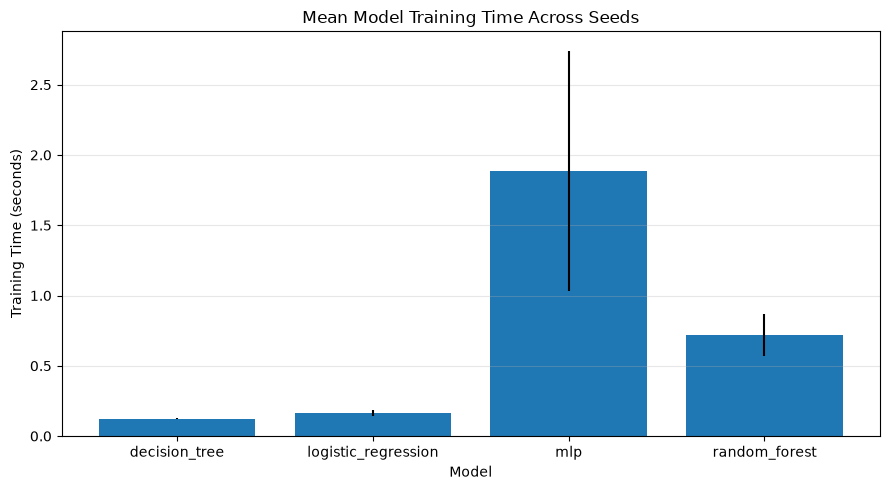

Saved: G:\Programming\xai\plots\03_model_training\training_time_comparison_all_seeds.png


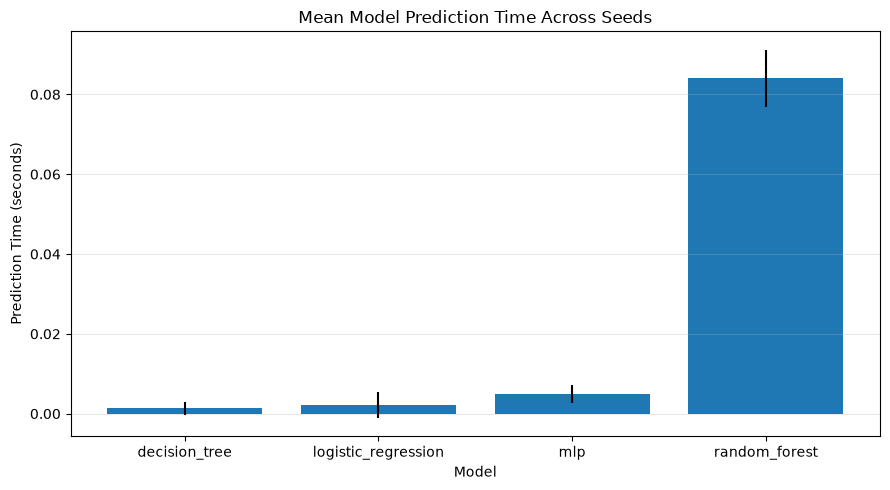

Saved: G:\Programming\xai\plots\03_model_training\prediction_time_comparison_all_seeds.png


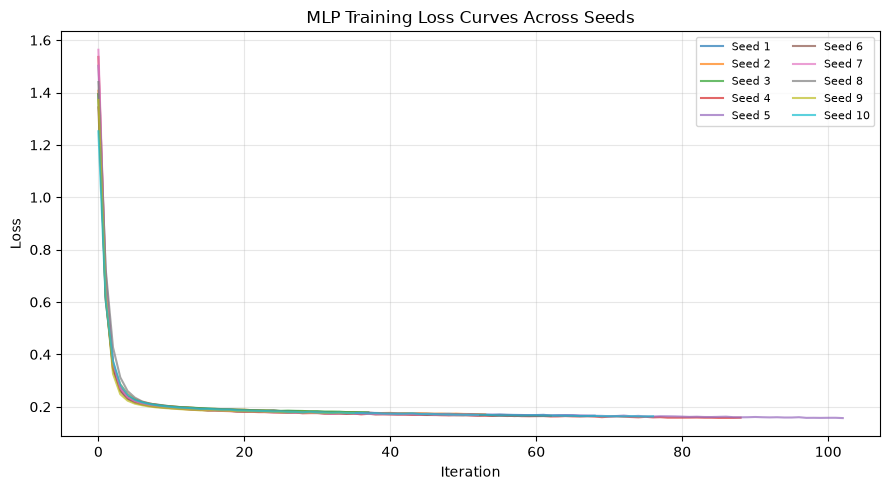

Saved: G:\Programming\xai\plots\03_model_training\mlp_loss_curves_all_seeds.png


In [13]:
import matplotlib.pyplot as plt

time_summary = (
    summary_df
    .groupby("model_name", as_index=False)
    .agg(
        training_time_mean=("training_time_seconds", "mean"),
        training_time_std=("training_time_seconds", "std"),
        prediction_time_mean=("prediction_time_seconds", "mean"),
        prediction_time_std=("prediction_time_seconds", "std")
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    time_summary["model_name"],
    time_summary["training_time_mean"],
    yerr=time_summary["training_time_std"].fillna(0)
)

plt.title("Mean Model Training Time Across Seeds")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "training_time_comparison_all_seeds.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")


plt.figure(figsize=(9, 5))

plt.bar(
    time_summary["model_name"],
    time_summary["prediction_time_mean"],
    yerr=time_summary["prediction_time_std"].fillna(0)
)

plt.title("Mean Model Prediction Time Across Seeds")
plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "prediction_time_comparison_all_seeds.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")


plt.figure(figsize=(9, 5))

for seed, seed_models in trained_models_by_seed.items():
    mlp_model = seed_models["mlp"]

    if hasattr(mlp_model, "loss_curve_"):
        plt.plot(
            mlp_model.loss_curve_,
            linewidth=1.5,
            alpha=0.7,
            label=f"Seed {seed}"
        )

plt.title("MLP Training Loss Curves Across Seeds")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)

plt.tight_layout()

plot_path = PLOTS_DIR / "mlp_loss_curves_all_seeds.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")
